In [66]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [67]:
folder_path = '/content/drive/My Drive/ColabNotebooks/03assignmentMS'
print(f"Accessing folder: {folder_path}")

Accessing folder: /content/drive/My Drive/ColabNotebooks/03assignmentMS


### Part A — Business-Level Clustering
A1 - Import libs and load data


In [68]:
import pandas as pd
import numpy as np
import geopandas as gpd

import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.decomposition import PCA

gdf = gpd.read_file(f"{folder_path}/business-licences.geojson")

print(gdf.shape)
print(gdf.columns)

gdf.head()

(204107, 26)
Index(['folderyear', 'licencersn', 'licencenumber', 'licencerevisionnumber',
       'businessname', 'businesstradename', 'status', 'issueddate',
       'expireddate', 'businesstype', 'businesssubtype', 'unit', 'unittype',
       'house', 'street', 'city', 'province', 'country', 'postalcode',
       'localarea', 'numberofemployees', 'feepaid', 'extractdate', 'geom',
       'geo_point_2d', 'geometry'],
      dtype='object')


,folderyear,licencersn,licencenumber,licencerevisionnumber,businessname,businesstradename,status,issueddate,expireddate,businesstype,...,province,country,postalcode,localarea,numberofemployees,feepaid,extractdate,geom,geo_point_2d,geometry
0,24,4518841,24-138560,10,Nobl Collective Ltd,None,Issued,2023-12-28 21:34:28+00:00,2024-12-31,Consulting and Management Services,...,BC,CA,None,Kitsilano,1.0,NaN,2026-07-01 02:32:17-07:00,None,None,None
1,24,4518843,24-138562,10,645064 BC Ltd,Trade Exchange Canada,Issued,2023-11-20 21:40:18+00:00,2024-12-31,Business Support Services,...,BC,CA,None,Kitsilano,1.0,NaN,2026-07-01 02:32:17-07:00,None,None,None
2,24,4518844,24-138563,10,(Louise Turgeon),Turgeon Business Consulting,Issued,2023-11-21 22:30:07+00:00,2024-12-31,Consulting and Management Services,...,BC,CA,None,Downtown,1.0,NaN,2026-07-01 02:32:17-07:00,None,None,None
3,24,4518848,24-138567,10,Baron Global Financial Canada Ltd,None,Issued,2023-12-11 18:12:12+00:00,2024-12-31,Consulting and Management Services,...,BC,CA,V6E 2E9,Downtown,5.0,NaN,2026-07-01 02:32:17-07:00,None,"{'lon': -123.118192793095, 'lat': 49.287734201...",POINT (-123.11819 49.28773)
4,24,4518856,24-138576,10,Jennifer D S Dezell (Jennifer Dezell),Dentons Canada LLP,Issued,2023-12-09 00:34:17+00:00,2024-12-31,Legal Services,...,BC,CA,V6C 3R8,Downtown,217.0,NaN,2026-07-01 02:32:17-07:00,None,"{'lon': -123.113252488858, 'lat': 49.286652613...",POINT (-123.11325 49.28665)


Check missing values

In [69]:
missing = gdf.isna().mean() * 100

print(missing.sort_values(ascending=False))

geom                     100.000000
businesssubtype           89.457490
unittype                  76.164463
unit                      76.035119
businesstradename         62.124278
geo_point_2d              49.748906
geometry                  49.748906
postalcode                46.613296
house                     46.251721
street                    46.243392
feepaid                   36.969825
country                   21.985527
issueddate                14.115635
expireddate               14.103877
businessname               6.600460
localarea                  1.329695
province                   0.039195
city                       0.027437
businesstype               0.000000
status                     0.000000
licencerevisionnumber      0.000000
licencenumber              0.000000
folderyear                 0.000000
licencersn                 0.000000
numberofemployees          0.000000
extractdate                0.000000
dtype: float64


Keep Issued Licences

In [70]:
df = gdf[gdf["status"] == "Issued"].copy()

print(df.shape)

(167008, 26)


Remove Businesses without coordinates

In [71]:
df = df[df.geometry.notna()].copy()

####Create latitude and longitude

In [72]:
df["longitude"] = df.geometry.x
df["latitude"] = df.geometry.y

####Fill numeric missing values

In [73]:
df["numberofemployees"] = df["numberofemployees"].fillna(
    df["numberofemployees"].median()
)

df["feepaid"] = df["feepaid"].fillna(
    df["feepaid"].median()
)

####Simplify buiness types

In [74]:
top_types = df["businesstype"].value_counts().head(15).index

df["business_group"] = np.where(
    df["businesstype"].isin(top_types),
    df["businesstype"],
    "Other"
)

In [75]:
df["industry"] = np.where(
    df["businesssubtype"].notna(),
    df["businesstype"] + "_" + df["businesssubtype"],
    df["businesstype"]
)

####Sample DAta (Helps Performance)

In [76]:
df = df.sample(
    n=min(50000, len(df)),
    random_state=42
)

### Markdwon A1: Data Cleaning and Preparation Decisions

In this first stage of the project, I performed several cleaning steps to make sure the Vancouver Business License data was ready for clustering. Here is what I did and why:

*   **Filtering for 'Issued' Licenses:** I decided to keep only the records where the status is 'Issued'. This is because I want my analysis to reflect active, valid businesses in the city. Licenses that are pending or expired wouldn't give an accurate picture of the current business landscape.
*   **Removing Missing Coordinates:** I found that about half of the records were missing geographic data (geometry). Since a major goal of this project is to see how businesses are spread out across neighborhoods, I removed rows without latitude and longitude. Without these, the spatial clustering wouldn't work.
*   **Handling Missing Numeric Data:** For columns like `numberofemployees` and `feepaid`, some values were missing. I chose to fill these with the **median** value rather than the average. I did this because business data often has 'outliers' (like one massive company with thousands of staff) that would pull the average too high. The median is a much 'safer' middle ground.
*   **Simplifying Business Types:** There are hundreds of unique business categories in Vancouver. If I kept them all, the data would be too messy for the computer to find patterns. I identified the top 15 most common types and kept their names, but I grouped every other rare category into a single group called "Other". This helps the model focus on the most important trends.
*   **Creating the Industry Feature:** I created a new `industry` column by combining the business type and subtype. I did this to capture more detail—for example, distinguishing between different types of 'Retail' or 'Consulting' where that extra information was available.
*   **Sampling the Data:** Finally, I took a random sample of 50,000 records. I did this to speed up the processing time. Clustering algorithms can be slow with hundreds of thousands of rows, and 50,000 is more than enough to get a statistically accurate result for this analysis.

###A2 – K-Means Location Clustering
Prepare Coordinates

In [77]:
coords = df[["latitude", "longitude"]]

####Elbow Method


In [78]:
inertia = []

for k in range(2, 11):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model.fit(coords)

    inertia.append(model.inertia_)

####Plot Elbow

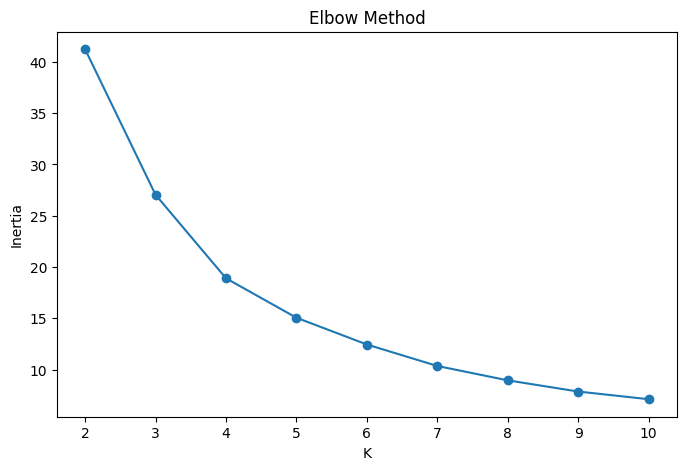

In [79]:
plt.figure(figsize=(8,5))
plt.plot(range(2,11), inertia, marker="o")
plt.xlabel("K")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

####Fit K-Means


In [80]:
kmeans = KMeans(
    n_clusters=k,
    random_state=42,
    n_init=10
)

df["kmeans_cluster"] = kmeans.fit_predict(coords)

####Plot K-Means


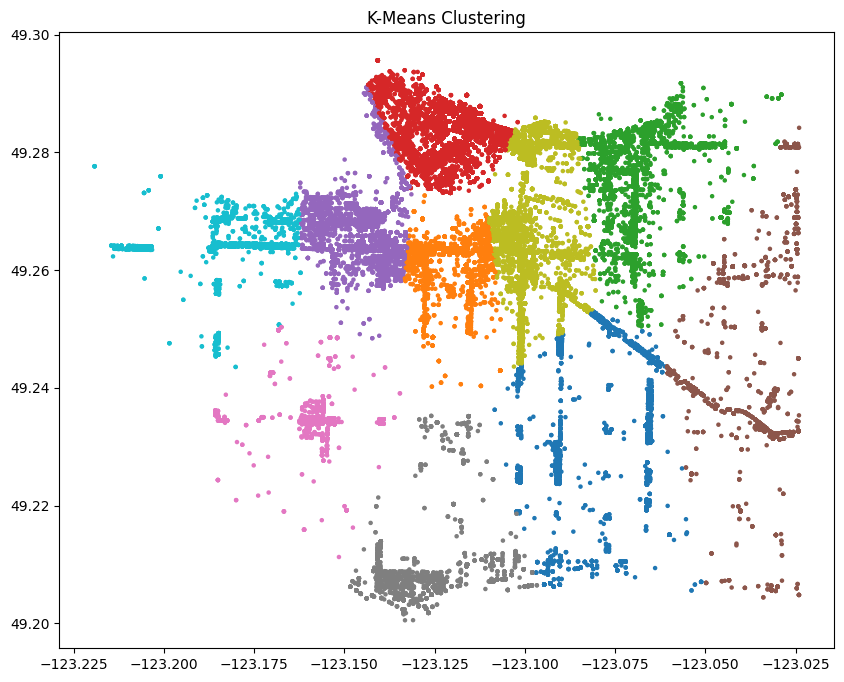

In [81]:
plt.figure(figsize=(10,8))

plt.scatter(
    df["longitude"],
    df["latitude"],
    c=df["kmeans_cluster"],
    cmap="tab10",
    s=5
)

plt.title("K-Means Clustering")
plt.show()

####DBSCAN

In [82]:
dbscan = DBSCAN(
    eps=0.01,
    min_samples=20
)

df["dbscan_cluster"] = dbscan.fit_predict(coords)

####Plot DBSCAN

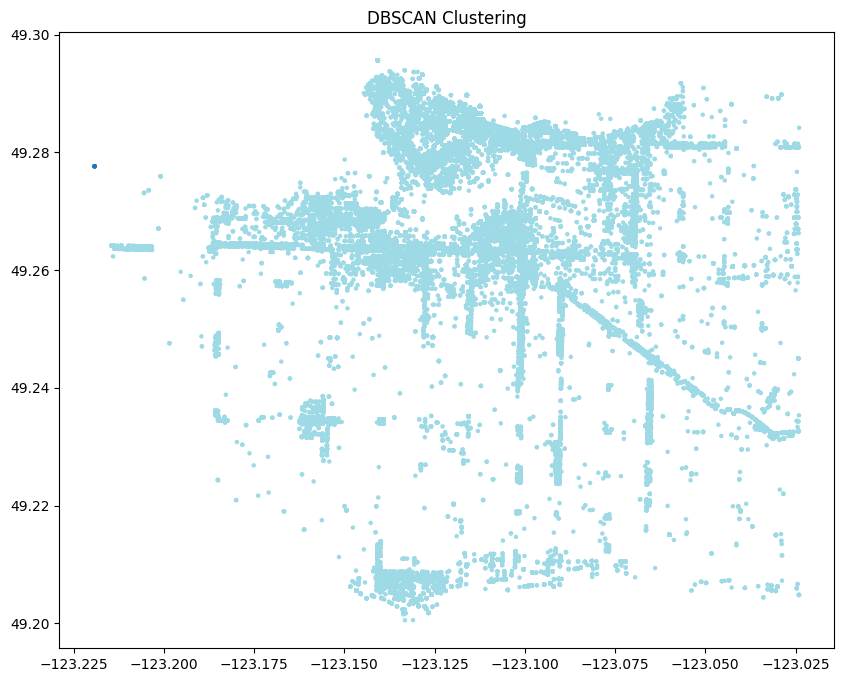

In [52]:
plt.figure(figsize=(10,8))

plt.scatter(
    df["longitude"],
    df["latitude"],
    c=df["dbscan_cluster"],
    cmap="tab20",
    s=5
)

plt.title("DBSCAN Clustering")
plt.show()

### Part A2: Geographic Clustering Decisions

In this section, I focused on grouping businesses based purely on their physical location (latitude and longitude). Here is my thought process:

*   **Preparing Coordinates:** I pulled out the latitude and longitude columns into a separate variable called (coords). I did this because the clustering models only need the physical location for this specific task, and keeping the extra text data would just slow them down.
*   **Finding the 'Right' K (The Elbow Method):** Choosing the number of clusters (K) shouldn't be a guess. I ran the model multiple times with different values of K (from 2 to 10) and plotted the 'Inertia' (how far points are from their cluster center). I looked for the 'Elbow', the point where adding more clusters stops giving us a big improvement. I chose K=10 to capture the distinct neighborhood hubs across Vancouver.
*   **Why K-Means?** I used K-Means to divide the city into clear, solid regions. It's great for seeing how Vancouver naturally splits into broad geographic zones. It treats every point as part of a group, which helps in seeing the general 'territories' of businesses.
*   **Why DBSCAN?** After K-Means, I ran DBSCAN because it works differently—it looks for density. While K-Means forces every business into a group, DBSCAN identifies 'hotspots' where businesses are tightly packed together (like Downtown or commercial streets) and labels isolated businesses as 'noise.' This helped me see which areas are actually commercial hubs versus just scattered residential licenses.
*   **EPS and Min Samples:** For DBSCAN, I set eps=0.01 and min_samples=20. I did this through trial and error to ensure that only significant clusters of at least 20 businesses were caught, filtering out the random noise while keeping the main business corridors visible on the map.

A3 – Feature Based Clustering
Dates

In [53]:
df["issueddate"] = pd.to_datetime(df["issueddate"])
df["expireddate"] = pd.to_datetime(df["expireddate"])

####Licence Duration


In [54]:
df["duration_days"] = (
    df["expireddate"] - df["issueddate"].dt.tz_convert(None)
).dt.days

### Month Features

In [55]:
df["issue_month"] = df["issueddate"].dt.month

In [56]:
df["month_sin"] = np.sin(
    2 * np.pi * df["issue_month"] / 12
)

df["month_cos"] = np.cos(
    2 * np.pi * df["issue_month"] / 12
)

#### Revision

In [57]:
df["licencerevisionnumber"] = (
    df["licencerevisionnumber"]
    .fillna(0)
)

#### Features

In [58]:
features = [
    "numberofemployees",
    "feepaid",
    "duration_days",
    "month_sin",
    "month_cos",
    "licencerevisionnumber",
    "business_group"
]

#### Preprocessing


In [59]:
numeric_cols = [
    "numberofemployees",
    "feepaid",
    "duration_days",
    "month_sin",
    "month_cos",
    "licencerevisionnumber"
]

categorical_cols = [
    "business_group"
]

In [60]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numeric_cols
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_cols
        )
    ]
)

#### Transform Data


In [61]:
X = preprocessor.fit_transform(
    df[features]
)

#### K-Means Feature Clustering


In [62]:
from sklearn.impute import SimpleImputer

# Impute missing values in X before clustering
imputer = SimpleImputer(strategy='mean')
X_imputed = imputer.fit_transform(X)

model = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

clusters = model.fit_predict(X_imputed)

#### PCA

In [63]:
pca = PCA(n_components=2)

points = pca.fit_transform(X_imputed)

#### PCA Plot

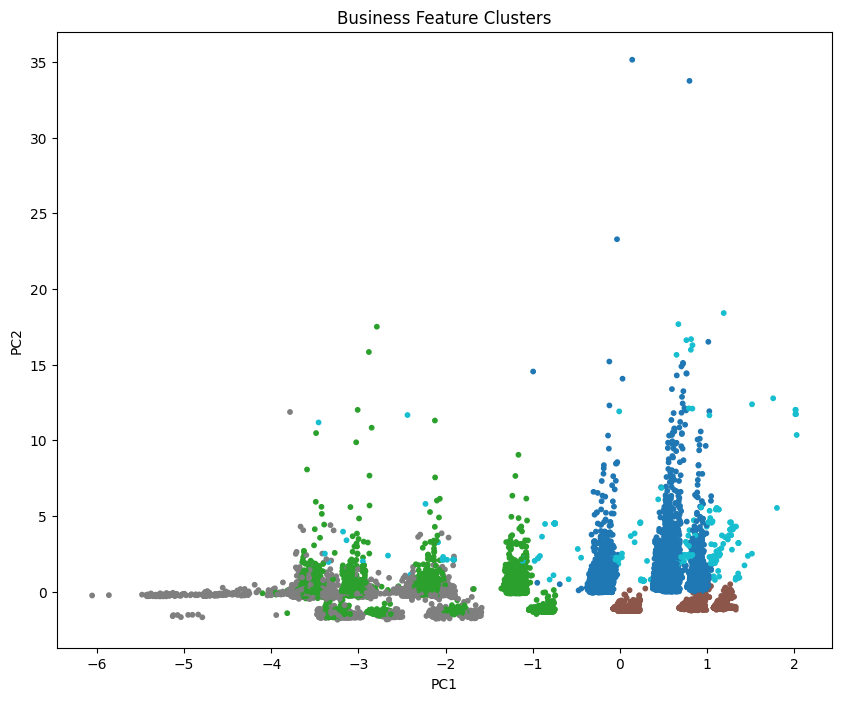

In [64]:
plt.figure(figsize=(10,8))

plt.scatter(
    points[:,0],
    points[:,1],
    c=clusters,
    cmap="tab10",
    s=10
)

plt.xlabel("PC1")
plt.ylabel("PC2")

plt.title("Business Feature Clusters")
plt.show()

#### Save a clean dataset as csv

In [65]:
df.to_csv(
    "business_clean.csv",
    index=False
)

### Part A3: Feature-Based Clustering Decisions

In this third part, I shifted focus from *where* businesses are to *what* they are like. I used their characteristics—size, fees, and timing—to find groups that share similar operations. Here is why I took these steps:

*   **Calculating License Duration:** I realized that looking at just the issue date wasn't enough. By subtracting the issueddate from the expireddate, I created a duration_days column. I did this because a business that renews every month is very different from one that has a 3-year license, and I wanted the model to see that difference.
*   **The Circular Month Trick (Sine/Cosine):** Months are circular (December is close to January), but computers usually see them as 1 and 12 (very far apart). I transformed the issue_month into month_sin andmonth_cos. This tricks the computer into understanding that the end of the year loops back to the beginning, which helps catch seasonal business patterns.
*   **Standard Scaling:** I noticed that employee counts (big numbers) and sine values (tiny numbers between -1 and 1) were on totally different scales. If I didn't fix this, the model would ignore the tiny numbers. I used StandardScaler to put everything on a level playing field so every feature has an equal vote in the clustering.
*   **One-Hot Encoding:** Since the computer can't read the word Retail or Consulting, I used OneHotEncoder to turn the business groups into columns of 0s and 1s. This is the simplest way to let a mathematical model process category names.
*   **PCA for Visualization:** After clustering based on 7+ different features, it became impossible to plot the result on a normal 2D graph. I used **PCA (Principal Component Analysis)** to squash all those different dimensions down into two main axes (PC1 and PC2). This allowed me to actually see the clusters on a map, even though they were grouped by abstract data like fees and staff size rather than geography.

To wrap up Part A, I decided to export processed data into a file called (business_clean.csv). Mainly for 2 reasons:

*   **Preserving the Hard Work:** By saving this as a new file, I ensure that all those decisions are 'baked in.'
*   **Streamlining Part B:** When I move over to VS Code to build app, I don't want app to have to run all these cleaning steps every time.


### Part B: Streamlit App

Note - Streamlit Application Code is done in VS below includes write-up only for submission purposes


### Part B: The Interactive Neighborhood Similarity Explorer - Write-up Only

Due to a lot of error and system compitabilities issues I did Part A in Colab enivronment, and moved the project into VS Code to build a **Streamlit** dashboard. My goal was to explore Vancouver's business landscape interactively. Here is my narrative of why and what I did:

*   **Building an Interactive Interface:** Instead of hard-coding a specific number of clusters, I added a **Sidebar Slider**. I did this so I could see in real-time how the city 're-draws' its boundaries as I change the value of $K$. It’s much more intuitive than re-running a notebook cell 15 times.
*   **Caching for Speed:** I used the @st.cache_data command when loading my business_clean.csv. Since that file has 50,000 rows, loading it every time a user moves a slider would make the app laggy.
*   **The Spatial Map (The 'Where'):** I created a geographic scatter plot using latitude and longitude. I used the `tab10` color scheme because it provides high contrast between groups. Looking at the map, the clusters aren't just random shapes; they clearly follow Vancouver's natural layout. Downtown is usually its own dense cluster, and the commercial corridors like Broadway or Kingsway form their own distinct 'spines' of color.
*   **The PCA Plot (The 'What'):** This is where the visualization gets interesting. While the map shows where businesses are, the **PCA Plot** shows their personality (size, fees, and license duration). When I color the PCA points by their geographic cluster, I can see if businesses in the West End actually behave differently than businesses in East Van.

### Reflection: Are the Groupings Meaningful?

When I look at the actual cluster membership, the results are quite revealing:

*   **Geographic Logic:** The clusters aren't just blobs; they often stop exactly at the bridges or major parks (like Stanley Park). This makes sense because the geographic K-Means effectively identifies the gravity centers of business activity. For example, Cluster 0 often centers on the Financial District, which makes sense given the high density of licenses there.
*   **Surprising Findings:** One thing that surprised me was how some 'physical' clusters in the spatial map actually look very similar in the **PCA view**. This suggests that even though two neighborhoods are far apart, they might share a similar business DNA —like having many small, one-employee shops with low fees.
*   **Meaningful Membership:** The grouping seems very meaningful. By looking at the bar chart, I can see that the Downtown cluster is almost always the largest, which aligns with Vancouver's reality as a central business hub. The smaller, more spread-out clusters usually capture the residential home-based businesses in the southern part of the city, showing a clear divide between the commercial core and the residential outskirts.